# POLISCI 3

## Week 11 Notebook Lecture 2: Bivariate regression

Welcome to Week 11, Notebook Lecture 2!

In the last Notebook Lecture, we saw how useful it is to be able to put a "**line of best fit**" on a graph. It really helps get a sense of trends in the data.

Now we're going to talk about how those lines of best fit are calculated and how we can use R to retrieve the formulas for them. The approach we use for this is called **bivariate regression**. The "bivariate" part is because we're just using two variables: a y-variable (vertical axis) and an x-variable (horizontal axis).

How is this line calculated? This is a bit technical and I don't need you to remember this _exactly_, but I want to understand the basics: **A bivariate regression line is formed by finding the line that minimizes the square of the vertical distances between the line and each of the points.**

I think this is easiest to see visually, by thinking of the best fit line as suspended from springs. Here's what this would look like for some of the happiness data from earlier in the class:

![](regressionexample.png)

One of the things this makes clear is that one data point way off from the others can have a big impact on the line of best fit. We call this an _outlier_.

![](withoutlier.png)

## Why is it called "regression"?

Last week, in discussing Campbell and Ross's study of the Connecticut Crackdown, we talked about the "regression effect," also known as "regression to the mean": the tendency of extreme values to revert to slightly less extreme values.  

This tendency is in fact what gives the regresssion line its name!

Let's use a figure from FPP's Statistics to help us understand this.  You should be sure to reach Chapters 9, 10, and 12 of the book (posted on bCourses) and may find it very useful to read/review Chapter 8 on correlation as well (this is posted under Module 3).

Galton (1822-1911) and Pearson (1857-1936) studied the relationship between the height of fathers and sons. 

Freedman et al. (2007: 171) plot height of sons at maturity against the height of their fathers. Each dot represents a father-son pair; the x-coordinate gives father's height and the y-coordinate gives son's height. 

The dotted ``SD line" passes through the point of averages (the average value of $x$ and average value of $y$) as well as all points that are an equal number of standard deviations away from average, for both variables.

<div>
<img src="Heights1.png" width="800"/>
</div>

However, the SD line does not provide the best way of predicting son's height, given father's height.  

For example, look at the vertical strip over a father's height of 72 inches:  most of the dots fall well below the standard deviation line. 

Very tall fathers have slightly shorter sons, on average. 
   
And very short fathers have slightly taller sons, on average.
   
This is the "regression effect" or "regression to the mean!" (Galton, not so charmingly, actually called this "regression to mediocrity.")

#### The usefulness of the regression line

So what is the best way to "predict" son's height from father's height?  Put differently, by how much is a unit increase in father's height associated, on average, with an increase in son's height? 

The regression line answers this question, if there is a linear relationship between the height of fathers and sons. \pause

The regression line passes through the point of averages (like the SD line), but unlike the SD line it also approximately passes through the average of each vertical strip. 

Indeed, we could plot the average value of $y$ for each value of $x$. The regression line approximates this ``graph of averages" (that is, it is a smoothed version of the graph of averages). 

Let's see what that looks like:

<div>
<img src="GraphAverages.png" width="800"/>
</div>

If the graph of averages follows a straight line, that line is the regression line. 

Also, if we fit the regression line to the (weighted) graph of averages, this line coincides with the regression line fitted to the original scatterplot.


### Getting the formula for the regression line (the line of best fit)

Remember algebra? You can describe a line by $y = mx + b$. That is:

$\text{Variable of Interest (y)} = \text{Slope of line of best fit (m)} * \text{Explanatory variable (x)} + \text{Y-Intercept of line of best fit (b)}$

The y-intercept is at what value of y the line crosses the y-axis; i.e., the value of the line when x is zero.

The slope is how much the line "rises" for every unit of increase in x.

<img src="ymxb.jpg">

So, this picture has a slope of 0.5 and an intercept of 1. The formula for this line is therefore $y = 0.5 * x + 1$.

Notice that we can use this formula to figure out where the line is (that is, what the value of y will be) for any value of x we give it. For example, where is the line when x = 5? $0.5 * 5 + 1 = 3.5$. And sure enough, that is what we see on the graph.

### Regression and correlation

In Week 3, we studied the correlation coefficient.  Remember, the correlation coefficient is a summary measure of the association of two variables.  It varies between -1 and 1.  When the correlation is 0, there is no association between the variables.

It turns out that correlation is strongly related to regression--in particular, to the slope of the regression line.

Let's see why.  Notice that the slope of the regression line is less steep than the slope of the SD line:
   - An increase of one SD above average father's height is associated, on average, with a gain of less than one SD in son's height.
   - In fact, it is associated with an increase of $r \times$SD of son's height, where $r$ is the coefficient of correlation between father's height and son's height.

So that clarifies the relationship between regression and correlation!

Let's use a little notation to clarify this. Letting $m$ denote the slope of the regression line, we have
\begin{equation}
m=r \cdot \frac{{\rm SD}_{y}}{{\rm SD}_{x}},
\end{equation}
where ${\rm SD}_{y}$ is the standard deviation of the y variable on the vertical axis of a scatterplot (son's height in our example above) and ${\rm SD}_{x}$ is the standard deviation of the x variable on the horizontal axis of a scatterplot (father's height in our example above)

So $r$ tells us how much shallower the regression line is than the SD line!  Remember that correlations range from -1 to 1.  When the correlation is 1 (or -1), the regression line is equal to the SD line!  Otherwise, it is shallower.  

And when the correlation is 0, the slope of the line of best fit (the regression line) is also 0: a rise in X is not associated with any rise in Y.

Why $r$ is the exactly right factor to use in the formula above goes a little beyond our focus right now.  

But essentially, using the formula is what makes the line the line of best fit---i.e., the line that minimizes the square of the vertical distances between the line and each of the points, like we saw at the start of this lecture. 



### Getting the formula for the line of best fit in R

Ok -- we're ready to move to some data analysis and apply what we've learned so far.

To get the formula for line of best fit of a dataset in R, we run this command:

```
summary(lm(y.variable ~ x.variable, data = data))
```

A little terminology:
- For the `y.variable`: We call this variable either "outcome variables" or "dependent variables" because they are the outcome we are trying to predict (or, if we have a causal interpretation, that we think might _depend_) on the other variable. Sometimes we also say "left hand side" variable.
- For the `x.variable`: We call this variable either "predictor variables," "independent variables," or "right hand side variables."

### Association vs. causation

However, despite the language of "independent" and "dependent" variables, it is critical remember that there might be no causal relationship at all---we might simply be summarizing the descriptive relationship between two variables.

In fact, much (or most?) of the time that regression is used, it is applied to observational (non-experimental) data where any claim of causation is quite tenuous.  In other words, regression is often used for description, not for analyzing causation.

Think of the relationship between father's heights and son's height.  The regression line helps us to predict the likeliest height for a son, given his father's height.  But no one is talking about intervening to make a father taller and seeing what height his son would be, counterfactually, in that case.  

For now, it's best to think about regression as mostly describing associations.  But when regression is applied to certain research designs---such as randomized experiments---the slope of a regression line *might* describe a causal relationship.

Let's now run our first bivariate regression in R.

## Data example

In [1]:
# RUN THIS CELL
options(warn = -1) # suppress warnings

library(ggplot2) # load ggplot2

data <- read.csv('broockman_skovron.csv')
head(data)

,republican,incumbent,marriage_perception,marriage_opinion,religexempt_perception,religexempt_opinion,gunsbanassault_perception,gunsbanassault_opinion
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,1,0,50,69,60,34,70,70
2,1,0,10,48,60,49,10,46
3,1,1,25,53,65,46,NA,58
4,0,0,50,67,30,38,NA,70
5,1,0,25,52,70,44,NA,60
6,0,1,NA,71,NA,35,NA,69


Here is an overview of what the columns in the dataset represent: 

- `republican`: whether the state legislator or state legislative candidate who answered the survey was a Republican (1 = Republican, 0 = Democrat)
- `incumbent`: whether the person who answered the survey was an incumbent representative (i.e., currently holds political office) (1 = already holds office, 0 = just a candidate)
- `marriage_perception`: what percent of the politician's constituents they think support same-sex marriage
- `marriage_opinion`: what percent of the politician's constituents actually support same-sex marriage
- `religexempt_perception`: what percent of the politician's constituents they think support allowing employers to refuse to cover birth control for employees if it violates their religious beliefs
- `religexempt_opinion`: what percent of the politician's constituents actually support allowing employers to refuse to cover birth control for employees if it violates their religious beliefs
- `gunsbanassault_perception`: what percent of the politician's constituents they think support banning assault weapons
- `gunsbanassault_opinion`: what percent of the politician's constituents actually support banning assault weapons

## Bivariate Regression

First, as a reminder, here's what the variables we are working with look like:

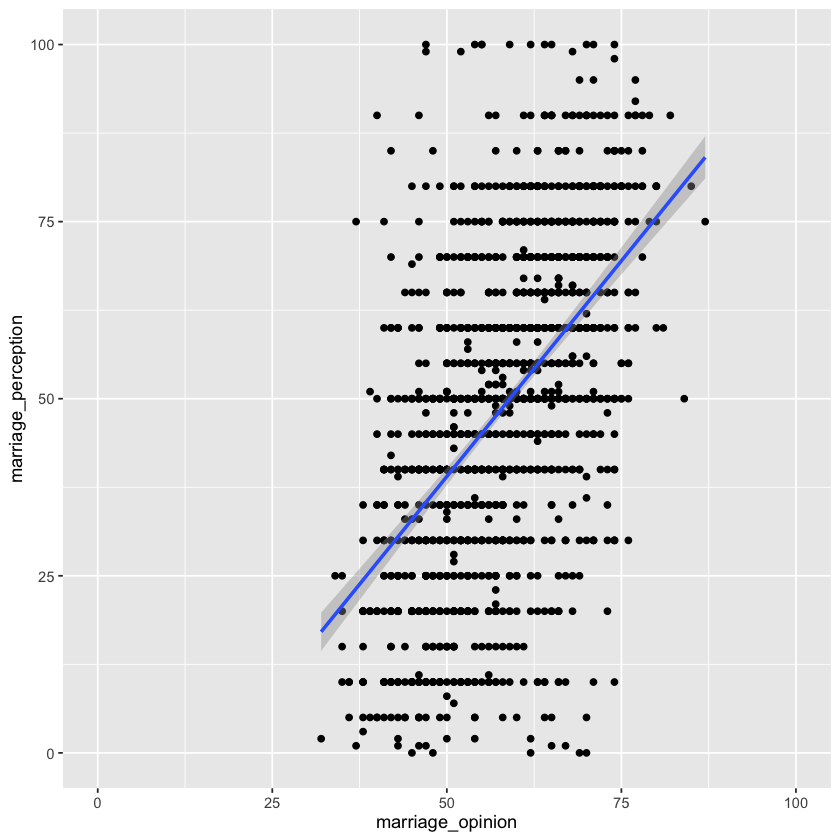

In [6]:
qplot(marriage_opinion, marriage_perception, data = data) + geom_smooth(formula = y ~x, method = 'lm') + xlim(0,100)

Now let's run a regression.

(Notice: the order for `qplot()` and `summary(lm())` are opposite!)

In this example, `marriage_perception` is our outcome/left hand side/dependent/y axis variable, and `marriage_opinion` is our predictor/right hand side/independent/x axis variable.

In [7]:
summary(lm(marriage_perception ~ marriage_opinion, data))


Call:
lm(formula = marriage_perception ~ marriage_opinion, data = data)

Residuals:
    Min      1Q  Median      3Q     Max 
-63.376 -12.287   1.019  12.197  64.633 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)      -21.86761    2.92840  -7.467 1.37e-13 ***
marriage_opinion   1.21777    0.04981  24.447  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 18.7 on 1527 degrees of freedom
  (29 observations deleted due to missingness)
Multiple R-squared:  0.2813,	Adjusted R-squared:  0.2808 
F-statistic: 597.7 on 1 and 1527 DF,  p-value: < 2.2e-16


Let's interpret each of these numbers:

- `(Intercept)` is showing us the **y-intercept** of the line of best fit. Literally interpreted, it is the line of best fit's best guess for what the value of y would be when x is zero. This doesn't necessarily need to make sense. In this case, there isn't any data at zero, and so we shouldn't literally predict that in a district where 0% of people supported same-sex marraige (the x variable) that the average politician would say -22% of people support it --- that number doesn't even make sense. It just means that, if we kept following the line of best fit, it would eventually hit the y axis at around -22.
- `marriage_opinion` shows the slope of the line of best fit. We also call this the "coefficient for `marriage_opinion`" because it shows us the $m$ that is multiplied by the $x$ (here, `marriage_opinion`).

We can do something pretty useful with these numbers! Say we want to form a best guess for what percent of politicians think their constituents support gay marriage in a district where 50% of voters actually do support gay marriage. That is, we want to know the $y$ in $y = mx + b$. We have $m$, $x$, and $b$, so we can do it!

- $b$ is the estimate for the `(Intercept)` term (-21.86761)
- $m$ is the estimate for the coefficeint on `marriage_opinion` (1.21777)
- $x$ we've set at 50%; this is the kind of district we want to know about

Let's plug this in:

In [2]:
best.guess.at.50 <- 1.21777 * 50 + -21.86761
best.guess.at.50

[1] 39.02089

### Don't extrapolate beyond the data!

Now we have a formula where we can take any value of $x$ (here, `marriage_opinion`) and get a best guess outcome/$y$ (here, `marriage_perception`). That is pretty cool!

But we need to be careful when we do this. The line of best fit can give us a best guess for _any_ value of $x$ we give it---it's just a formula. But some values of $x$ don't make sense to use because there is no data there!

Let's take a look at the graph again.

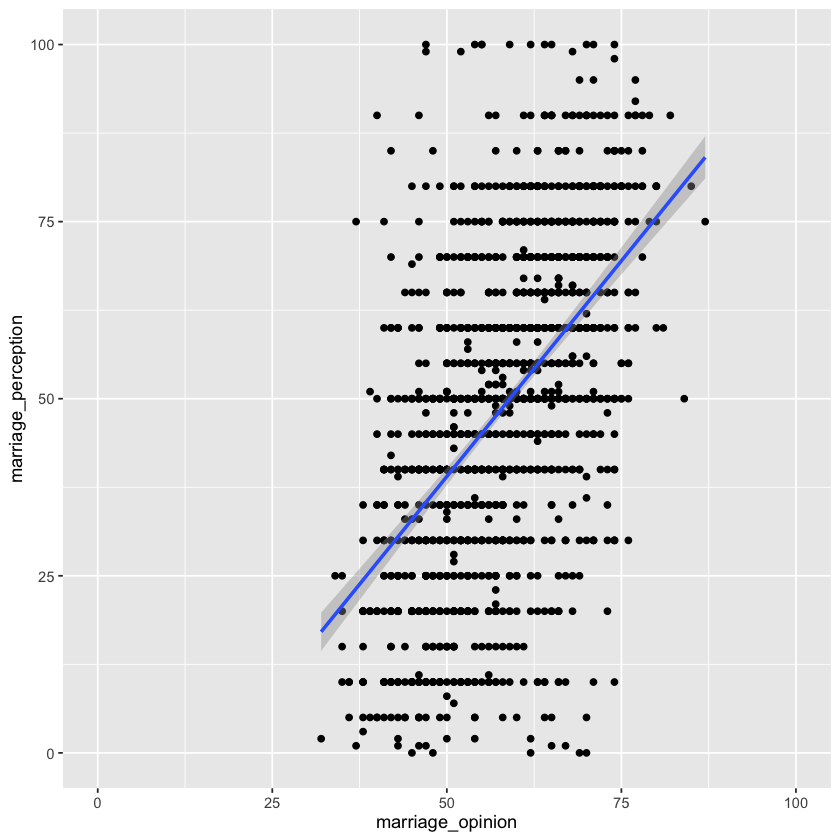

In [9]:
qplot(marriage_opinion, marriage_perception, data = data) + geom_smooth(formula=y~x,method = 'lm') + xlim(0,100)

The district in the entire country that is estimated to be most conservative is estimated to have 32% of its people support same-sex marriage:

In [10]:
min(data$marriage_opinion, na.rm = T)

[1] 32

So, we *could* compute our best guess of how legislators would percieve a hypothetical district at 10% support:

In [11]:
-21.86 + 1.21 * 10

[1] -9.76

...but **this would be a bad idea**. There isn't any data there, and so we're looking past the domain of the data. Marriage opinion is never below 32, so we shouldn't extrapolate to values where data doesn't exist; our answers could be non-sensical.

For example, the `(Intercept)` is telling us what the regression's best guess is when x = 0 --- i.e., in a district where no voters supported same-sex marriage, what would a politician percieve support as? There's no data here, though, and so the answer we get from the regression is non-sensical (the intercept is at -22%).

This is part of why it's so important to plot our data visually when we want to make predictions: we can make sure we aren't extrapolating outside of where we have data.

## Summary

In the two Notebook Lectures for Week 11, you have learned:
- Some new tools for visualizing data in R, such as scatterplots using the `ggplot2` package;
- How to fit a line of best fit---the regression line---to such a scatterplot; and
- What the line means---for example, how to interpret its intercept and slope, and why we call it the "regression" line.

In Week 12, we'll practice reading output from a table of regression results and also learn about the uses (and misuses) of *multivariate* regression---i.e., regression with more than two variables.

## In-class activity on Tuesday

In the Week 11 in-class activity on Tuesday, you will practice the skills we have learned in Notebook Lectures 1 and 2 this week.  

In particular, you will practice visualizing data and fiting regressions, using the same Broockman and Skovron data we have used in these lectures.  And you'll answer some conceptual questions about the material we have covered.  

It will be helpful to do the reading and to review these lecture notes carefully!  As usual, we will put syntax for R routines you will need on the R Cheat Sheet.